# AAI 501 Final Team Project  
## Intelligent Predictive Maintenance for NASA C-MAPSS Turbofan Engines

**Objective:** Predict Remaining Useful Life (RUL), compare classical ML and recurrent neural networks, and convert the selected model's predictions into a capacity-constrained maintenance queue.


## Executive summary

The notebook follows one leakage-safe workflow:

1. Load FD001 and construct capped RUL labels.
2. Perform degradation-focused EDA.
3. Engineer causal rolling features for tabular models.
4. Create one engine-level train/validation split and reuse it for every model.
5. Compare mean, linear, ridge, random forest, gradient boosting, and XGBoost models.
6. Compare configurable LSTM and GRU architectures on 30-cycle windows.
7. Retrain selected recurrent models on all 100 training engines.
8. Evaluate once on the official 100-engine FD001 test set.
9. Convert the final RUL predictions into a PEAS-framed maintenance queue.

# 1. Setup, paths, and reproducibility

In [81]:
from pathlib import Path
import copy
import json
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, RandomizedSearchCV, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42
RUL_CAP = 125
SEQUENCE_LENGTH = 30
BATCH_SIZE = 256
MAX_EPOCHS = 60
PATIENCE = 8

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [5]:
from pathlib import Path

def find_project_root() -> Path:
    """
    Locate the project repository.

    Search order:
    1. Preferred GitHub repository
    2. Current working directory
    3. Parent directories
    """

    # Preferred location for this project
    github_repo = (
        Path.home()
        / "Documents"
        / "GitHub"
        / "intelligent-predictive-maintenance"
    )

    if github_repo.exists():
        return github_repo.resolve()

    # Fallback: search upward from current working directory
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (
            (candidate / "datasets").exists()
            and (candidate / "outputs").exists()
        ):
            return candidate.resolve()

    raise FileNotFoundError(
        "Could not locate the project repository."
    )


# ---------------------------------------------------------
# Project directories
# ---------------------------------------------------------
PROJECT_ROOT = find_project_root()

DATASETS_DIR = PROJECT_ROOT / "datasets"

RAW_DIR = DATASETS_DIR / "raw" / "CMAPSSData"
PROCESSED_DIR = DATASETS_DIR / "processed"
PREDICTIONS_DIR = DATASETS_DIR / "predictions"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
MODELS_DIR = OUTPUTS_DIR / "models"
REPORTS_DIR = OUTPUTS_DIR / "reports"

# Create output folders if they do not already exist
for directory in [
    PROCESSED_DIR,
    PREDICTIONS_DIR,
    FIGURES_DIR,
    MODELS_DIR,
    REPORTS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("RAW_DIR      :", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("OUTPUTS_DIR  :", OUTPUTS_DIR)

PROJECT_ROOT : /Users/sudhakaransrinivasan/Documents/GitHub/intelligent-predictive-maintenance
RAW_DIR      : /Users/sudhakaransrinivasan/Documents/GitHub/intelligent-predictive-maintenance/datasets/raw/CMAPSSData
PROCESSED_DIR: /Users/sudhakaransrinivasan/Documents/GitHub/intelligent-predictive-maintenance/datasets/processed
OUTPUTS_DIR  : /Users/sudhakaransrinivasan/Documents/GitHub/intelligent-predictive-maintenance/outputs


# 2. Load FD001 and create the RUL target

In [42]:
COLUMNS = (
    ["unit_id", "cycle", "setting_1", "setting_2", "setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

def read_cmapss_file(path):
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")

    frame = pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        names=COLUMNS,
    )
    return frame

train_raw = read_cmapss_file(RAW_DIR / "train_FD001.txt")
test_raw = read_cmapss_file(RAW_DIR / "test_FD001.txt")

test_rul = pd.read_csv(
    RAW_DIR / "RUL_FD001.txt",
    sep=r"\s+",
    header=None,
    names=["actual_rul"],
)
test_rul.insert(0, "unit_id", np.arange(1, len(test_rul) + 1))

print("Train shape:", train_raw.shape)
print("Test shape:", test_raw.shape)
print("Training engines:", train_raw["unit_id"].nunique())
print("Test engines:", test_raw["unit_id"].nunique())
display(train_raw.head())

Train shape: (20631, 26)
Test shape: (13096, 26)
Training engines: 100
Test engines: 100


,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [7]:
# Full run-to-failure labels are available only for the training engines.
max_cycles = (
    train_raw.groupby("unit_id", as_index=False)["cycle"]
    .max()
    .rename(columns={"cycle": "max_cycle"})
)

train = train_raw.merge(max_cycles, on="unit_id", how="left")
train["rul"] = train["max_cycle"] - train["cycle"]
train["rul_capped"] = train["rul"].clip(upper=RUL_CAP)

# The official test truth corresponds to each test engine's final observed cycle.
test_last_truth = test_rul.copy()

assert train["rul"].min() == 0
assert test_last_truth["actual_rul"].notna().all()

display(train[["unit_id", "cycle", "max_cycle", "rul", "rul_capped"]].head())

,unit_id,cycle,max_cycle,rul,rul_capped
0,1,1,192,191,125
1,1,2,192,190,125
2,1,3,192,189,125
3,1,4,192,188,125
4,1,5,192,187,125


### Why cap RUL at 125?

Early in an engine's life, sensor readings usually remain healthy despite a high RUL. As commonly done in the predictive maintenance literature, we cap the RUL at 125 cycles to focus the model on the degradation phase. We retain both rul and rul_capped so the effect of this assumption is transparent.

# 3. Data quality and degradation-focused EDA

In [43]:
quality_summary = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "missing": train.isna().sum(),
    "unique": train.nunique(),
    "std": train.std(numeric_only=True),
})

display(quality_summary.head(30))
print("Duplicate rows:", train.duplicated().sum())

,dtype,missing,unique,std
cycle,int64,0,362,6.888099e+01
life_stage,category,0,3,NaN
max_cycle,int64,0,66,5.002860e+01
rul,int64,0,362,6.888099e+01
rul_capped,int64,0,126,4.167370e+01
sensor_1,float64,0,1,0.000000e+00
sensor_10,float64,0,1,0.000000e+00
sensor_11,float64,0,159,2.670874e-01
sensor_12,float64,0,427,7.375534e-01
sensor_13,float64,0,56,7.191892e-02


Duplicate rows: 0


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


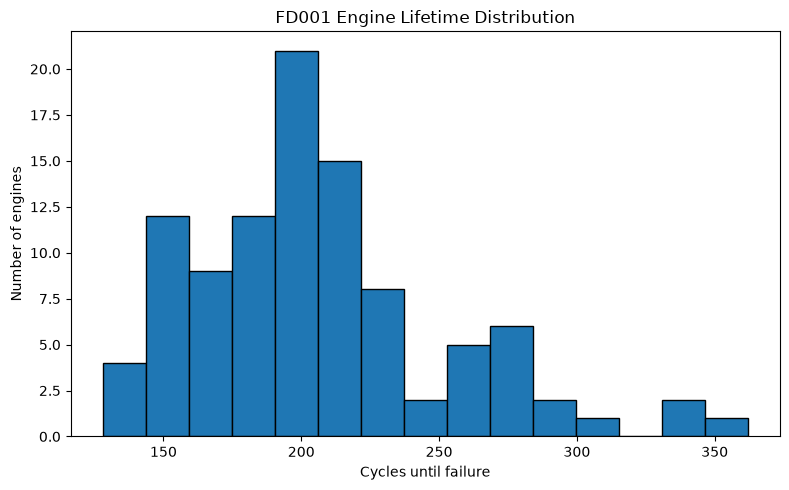

In [44]:
engine_life = train.groupby("unit_id")["cycle"].max()

print(engine_life.describe())

plt.figure(figsize=(8, 5))
plt.hist(engine_life, bins=15, edgecolor="black")
plt.xlabel("Cycles until failure")
plt.ylabel("Number of engines")
plt.title("FD001 Engine Lifetime Distribution")
plt.tight_layout()
plt.show()

In [10]:
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]
setting_cols = ["setting_1", "setting_2", "setting_3"]

# Near-constant channels provide little useful variation.
low_variance_cols = [
    column
    for column in setting_cols + sensor_cols
    if train[column].std() < 1e-8
]

selected_sensors = [
    sensor for sensor in sensor_cols
    if sensor not in low_variance_cols
]

print("Low-variance columns:", low_variance_cols)
print("Selected sensors:", selected_sensors)

Low-variance columns: ['setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Selected sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [45]:
correlation_table = pd.DataFrame({
    "corr_with_cycle": train[selected_sensors].corrwith(train["cycle"]),
    "corr_with_rul": train[selected_sensors].corrwith(train["rul_capped"]),
}).sort_values(
    "corr_with_rul",
    key=lambda values: values.abs(),
    ascending=False,
)

display(correlation_table)

,corr_with_cycle,corr_with_rul
sensor_11,0.634385,-0.775230
sensor_4,0.624577,-0.757157
sensor_12,-0.611354,0.748870
sensor_7,-0.595914,0.733021
sensor_15,0.588676,-0.720858
sensor_21,-0.585923,0.707334
sensor_20,-0.583597,0.704626
sensor_17,0.566995,-0.680829
sensor_2,0.549898,-0.678458
sensor_3,0.543947,-0.655030


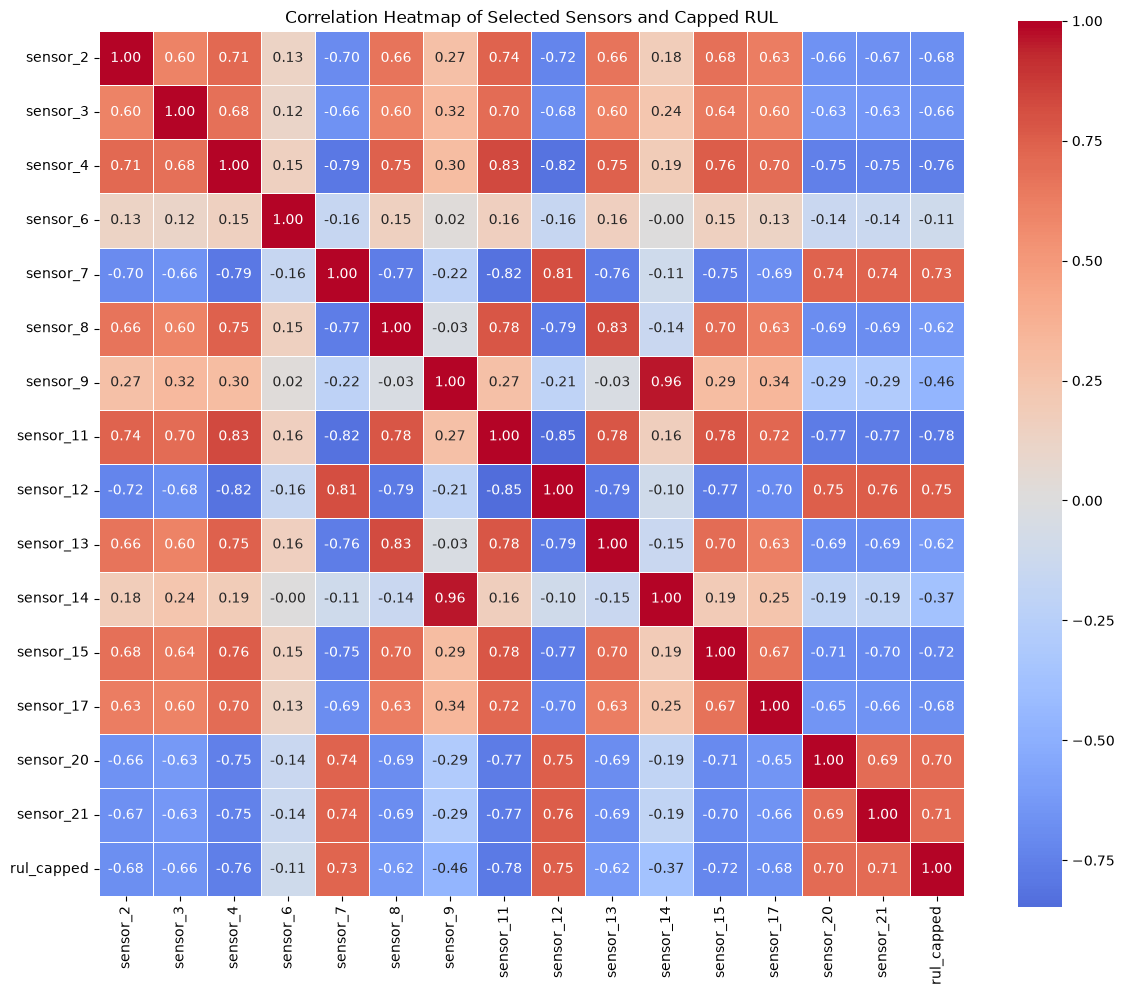

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix
corr_matrix = train[selected_sensors + ["rul_capped"]].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Selected Sensors and Capped RUL")
plt.tight_layout()
plt.show()

### Interpretation

The heatmap shows how the selected sensors relate to each other and to the capped Remaining Useful Life (RUL). Several sensors, such as sensor_11, sensor_12, sensor_15, sensor_20, and sensor_21, have relatively strong correlations with rul_capped, suggesting they contain useful information for predicting engine health. The heatmap also shows that some sensors are highly correlated with one another, meaning they capture similar patterns in the engine's behavior. Overall, the selected sensors appear to provide meaningful information about engine degradation, making them suitable inputs for the prediction models.

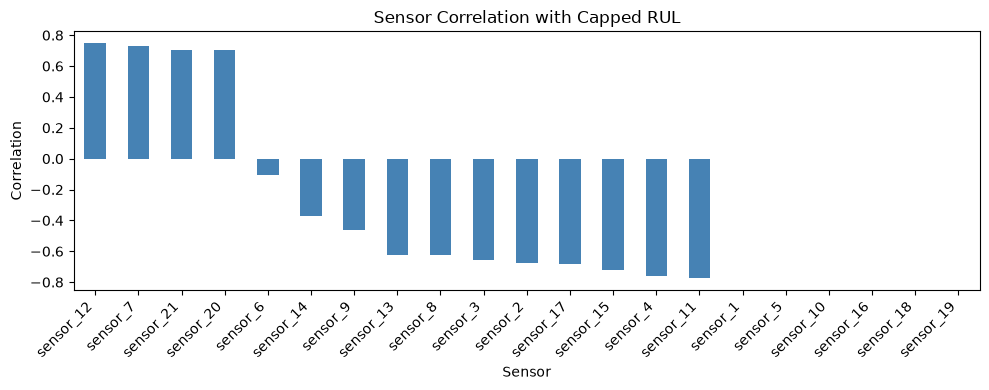

Top 5 sensors by absolute correlation with capped RUL:
['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_15']


In [52]:
# Sensor columns
sensor_cols = [c for c in train.columns if c.startswith("sensor_")]

# Correlation matrix
corr = train[["rul_capped"] + sensor_cols].corr()

# Correlation of each sensor with capped RUL
corr_with_rul = corr["rul_capped"].drop("rul_capped")

# ---- Plot: ordered by actual correlation ----
corr_plot = corr_with_rul.sort_values(ascending=False)

plt.figure(figsize=(10, 4))
corr_plot.plot(kind="bar", color="steelblue")
plt.title("Sensor Correlation with Capped RUL")
plt.xlabel("Sensor")
plt.ylabel("Correlation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ---- Select top sensors using absolute correlation ----
top_k = 5

top_sensors = (
    corr_with_rul.abs()
    .sort_values(ascending=False)
    .head(top_k)
    .index
    .tolist()
)

print(f"Top {top_k} sensors by absolute correlation with capped RUL:")
print(top_sensors)

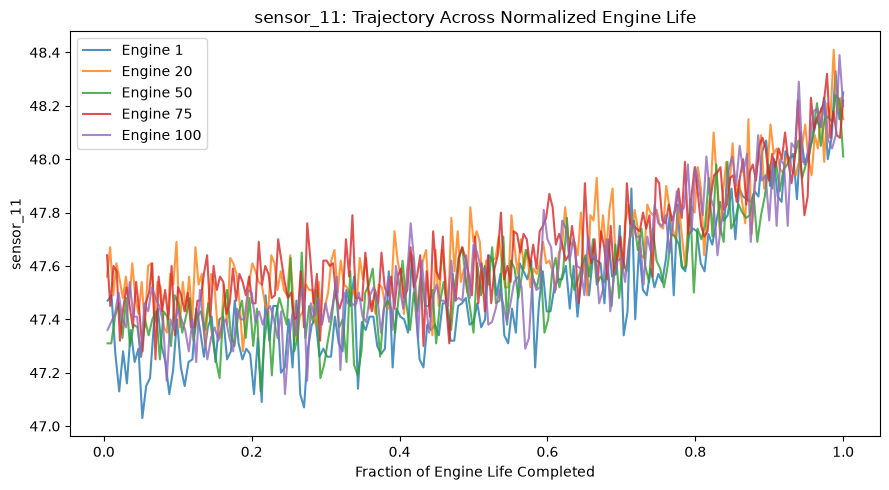

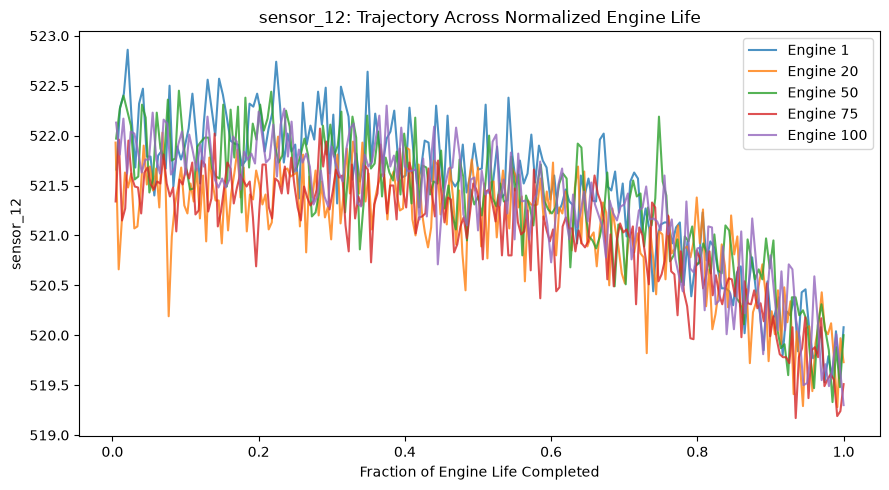

In [48]:
# Compare trajectories for sensor_11 and sensor_12 after normalizing each engine's lifetime.
example_engines = [1, 20, 50, 75, 100]
sensors_to_plot = ["sensor_11", "sensor_12"]

for sensor in sensors_to_plot:
    plt.figure(figsize=(9, 5))

    for engine_id in example_engines:
        engine = train[train["unit_id"] == engine_id]
        life_fraction = engine["cycle"] / engine["max_cycle"]

        plt.plot(
            life_fraction,
            engine[sensor],
            label=f"Engine {engine_id}",
            alpha=0.8,
        )

    plt.title(f"{sensor}: Trajectory Across Normalized Engine Life")
    plt.xlabel("Fraction of Engine Life Completed")
    plt.ylabel(sensor)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Interpretation

The trajectory plots show how sensor values change as engines progress through their lifetime. Although individual engines have different operating patterns, sensors such as sensor_11 and sensor_12 exhibit consistent trends as the engines approach the end of their life. This indicates that these sensors capture degradation patterns that are useful for predicting Remaining Useful Life

#### How do the important sensors behave during the early, middle, and late stages of an engine's life

In [14]:
train["life_stage"] = pd.cut(
    train["cycle"] / train["max_cycle"],
    bins=[0.0, 0.33, 0.67, 1.0],
    labels=["Early", "Middle", "Late"],
    include_lowest=True,
)

life_stage_summary = (
    train.groupby("life_stage", observed=False)[top_sensors]
    .mean()
    .T
)

display(life_stage_summary)

life_stage,Early,Middle,Late
sensor_11,47.361125,47.461917,47.799439
sensor_4,1402.993344,1406.310261,1417.464147
sensor_12,521.891528,521.628854,520.722648
sensor_7,553.923362,553.629270,552.553328
sensor_15,8.419186,8.430969,8.476172
sensor_21,23.356571,23.319090,23.193836
sensor_20,38.928038,38.865065,38.656353
sensor_17,392.299099,392.789970,394.538092


# 4. Leakage-safe feature engineering

In [55]:
def add_temporal_features(
    df: pd.DataFrame,
    sensors: list[str],
    windows: tuple[int, ...] = (5, 10),
) -> pd.DataFrame:
    """Create recent-change and rolling features separately for each engine."""

    # Sort observations so each engine's cycles are in the correct order.
    result = df.sort_values(["unit_id", "cycle"]).copy()

    # Group the data by engine.
    grouped = result.groupby("unit_id", group_keys=False)

    for sensor in sensors:
        # Change from the previous cycle.
        result[f"{sensor}_diff_1"] = (
            grouped[sensor]
            .diff()
            .fillna(0.0)
        )

        for window in windows:
            # Rolling calculations use only the current and previous cycles.
            rolling = grouped[sensor].rolling(
                window=window,
                min_periods=1,
            )

            result[f"{sensor}_roll_mean_{window}"] = (
                rolling.mean()
                .reset_index(level=0, drop=True)
            )

            result[f"{sensor}_roll_std_{window}"] = (
                rolling.std()
                .reset_index(level=0, drop=True)
                .fillna(0.0)
            )

            # Difference between the current reading and its recent average.
            result[f"{sensor}_minus_mean_{window}"] = (
                result[sensor]
                - result[f"{sensor}_roll_mean_{window}"]
            )

    return result


# Use the six sensors with the strongest absolute correlation with capped RUL.
engineered_sensors = (
    corr_with_rul.abs()
    .sort_values(ascending=False)
    .head(6)
    .index
    .tolist()
)

# Create temporal features separately for training and test data.
train_features = add_temporal_features(
    train,
    engineered_sensors,
)

test_features = add_temporal_features(
    test_raw,
    engineered_sensors,
)

print("Engineered sensors:", engineered_sensors)
print("Train feature shape:", train_features.shape)
print("Test feature shape:", test_features.shape)

Engineered sensors: ['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_15', 'sensor_21']
Train feature shape: (20631, 72)
Test feature shape: (13096, 68)


### Feature-engineering 

Temporal features were created for the six sensors most strongly related to capped RUL. These features capture the change from the previous cycle, the recent average, recent variation, and how far the current reading is from its recent average. The calculations were performed separately for each engine and used only the current and earlier cycles, so future information was not included.

In [56]:
# Check train and test column differences.
train_only_cols = set(train_features.columns) - set(test_features.columns)
test_only_cols = set(test_features.columns) - set(train_features.columns)

print("Train-only columns:", train_only_cols)
print("Test-only columns:", test_only_cols)

# Create the processed-data folder if it does not already exist.
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

metadata = {
    "rul_cap": RUL_CAP,
    "selected_sensors": selected_sensors,
    "engineered_sensors": engineered_sensors,
    "low_variance_cols": low_variance_cols,
    "train_rows": int(len(train_features)),
    "test_rows": int(len(test_features)),
    "train_engines": int(train_features["unit_id"].nunique()),
    "test_engines": int(test_features["unit_id"].nunique()),
}

train_features.to_csv(
    PROCESSED_DIR / "fd001_train_processed.csv",
    index=False,
)

test_features.to_csv(
    PROCESSED_DIR / "fd001_test_processed.csv",
    index=False,
)

test_last_truth.to_csv(
    PROCESSED_DIR / "fd001_test_last_with_rul.csv",
    index=False,
)

correlation_table.to_csv(
    PROCESSED_DIR / "fd001_sensor_correlations.csv"
)

with open(PROCESSED_DIR / "fd001_metadata.json", "w") as file:
    json.dump(metadata, file, indent=2)

print("Saved processed data to:", PROCESSED_DIR)

Train-only columns: {'life_stage', 'max_cycle', 'rul', 'rul_capped'}
Test-only columns: set()
Saved processed data to: /Users/sudhakaransrinivasan/Documents/GitHub/intelligent-predictive-maintenance/datasets/processed


fd001_train_processed.csv — processed training data with engineered features

fd001_test_processed.csv — processed test data with the same feature engineering

fd001_test_last_with_rul.csv — final test row for each engine with the true RUL

fd001_sensor_correlations.csv — correlation results used for sensor selection

fd001_metadata.json — records the preprocessing choices and dataset details

# 5. Shared evaluation functions and engine-level split

In [57]:
def rmse(y_true, y_pred) -> float:
    return float(mean_squared_error(y_true, y_pred) ** 0.5)


def cmapss_score(y_true, y_pred) -> float:
    """NASA asymmetric score; overestimated RUL is penalized more heavily."""
    error = np.asarray(y_pred) - np.asarray(y_true)
    penalties = np.where(
        error < 0,
        np.exp(-error / 13.0) - 1.0,
        np.exp(error / 10.0) - 1.0,
    )
    return float(penalties.sum())


def evaluate_regression(y_true, y_pred, model_name: str) -> dict:
    return {
        "model": model_name,
        "rmse": rmse(y_true, y_pred),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "cmapss_score": cmapss_score(y_true, y_pred),
    }

In [58]:
excluded = {
    "unit_id",
    "max_cycle",
    "rul",
    "rul_capped",
    "life_stage",
}
# Keep cycle as a feature because engine age provides useful context.

feature_cols = [
    column
    for column in train_features.columns
    if column not in excluded
]
target_col = "rul_capped"

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

train_idx, val_idx = next(
    splitter.split(
        train_features[feature_cols],
        train_features[target_col],
        groups=train_features["unit_id"],
    )
)

train_part = train_features.iloc[train_idx].copy()
val_part = train_features.iloc[val_idx].copy()

X_train = train_part[feature_cols]
y_train = train_part[target_col]
X_val = val_part[feature_cols]
y_val = val_part[target_col]

assert not (
    set(train_part["unit_id"])
    & set(val_part["unit_id"])
)

print("Training engines:", train_part["unit_id"].nunique())
print("Validation engines:", val_part["unit_id"].nunique())
print("Tabular features:", len(feature_cols))

Training engines: 80
Validation engines: 20
Tabular features: 67


# 6. Baseline and tree-based models

In [59]:
# 6. Baseline models

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
)

# Store results and validation predictions.
model_results = []
validation_predictions = {}


# 6.1 Mean baseline
# Predict the average training RUL for every validation row.
mean_val_pred = np.repeat(
    y_train.mean(),
    len(y_val),
)

model_results.append(
    evaluate_regression(
        y_val,
        mean_val_pred,
        "Mean Baseline",
    )
)

validation_predictions["Mean Baseline"] = mean_val_pred


# 6.2 Linear Regression
# Scaling is useful because Linear Regression is sensitive to feature scale.
linear_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

linear_pipeline.fit(X_train, y_train)

linear_val_pred = np.clip(
    linear_pipeline.predict(X_val),
    0,
    RUL_CAP,
)

model_results.append(
    evaluate_regression(
        y_val,
        linear_val_pred,
        "Linear Regression",
    )
)

validation_predictions["Linear Regression"] = linear_val_pred


# 6.3 Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)

rf_val_pred = np.clip(
    rf_model.predict(X_val),
    0,
    RUL_CAP,
)

model_results.append(
    evaluate_regression(
        y_val,
        rf_val_pred,
        "Random Forest",
    )
)

validation_predictions["Random Forest"] = rf_val_pred


# 6.4 Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
)

gb_model.fit(X_train, y_train)

gb_val_pred = np.clip(
    gb_model.predict(X_val),
    0,
    RUL_CAP,
)

model_results.append(
    evaluate_regression(
        y_val,
        gb_val_pred,
        "Gradient Boosting",
    )
)

validation_predictions["Gradient Boosting"] = gb_val_pred


# 6.5 Baseline comparison
baseline_comparison = (
    pd.DataFrame(model_results)
    .sort_values(["rmse", "mae"])
    .reset_index(drop=True)
)

display(
    baseline_comparison.style.format({
        "rmse": "{:.2f}",
        "mae": "{:.2f}",
        "cmapss_score": "{:,.0f}",
    })
)

,model,rmse,mae,cmapss_score
0,Gradient Boosting,14.80,10.23,"16,628"
1,Random Forest,15.37,10.12,"19,727"
2,Linear Regression,17.06,12.88,"19,908"
3,Mean Baseline,41.72,36.93,"1,285,856"


Linear Regression provides a simple linear benchmark, while Random Forest and Gradient Boosting can capture more complex relationships between sensor readings and RUL. Their performance is also compared with a mean baseline, which predicts the same average RUL for every observation.

### Baseline feature importance

In [60]:
# Compare feature importance from Random Forest and Gradient Boosting.

baseline_importance = pd.DataFrame({
    "feature": feature_cols,
    "random_forest": rf_model.feature_importances_,
    "gradient_boosting": gb_model.feature_importances_,
})

rf_top_features = (
    baseline_importance
    .sort_values("random_forest", ascending=False)
    .head(15)
)

gb_top_features = (
    baseline_importance
    .sort_values("gradient_boosting", ascending=False)
    .head(15)
)

display(rf_top_features)
display(gb_top_features)

,feature,random_forest,gradient_boosting
36,sensor_4_roll_mean_10,0.388616,0.135959
33,sensor_4_roll_mean_5,0.225530,0.196308
0,cycle,0.145892,0.138894
29,sensor_11_roll_mean_10,0.048493,0.045358
57,sensor_15_roll_mean_10,0.036677,0.144980
12,sensor_9,0.035019,0.031525
64,sensor_21_roll_mean_10,0.021565,0.040174
26,sensor_11_roll_mean_5,0.014677,0.121921
54,sensor_15_roll_mean_5,0.013631,0.062986
17,sensor_14,0.013030,0.018151


,feature,random_forest,gradient_boosting
33,sensor_4_roll_mean_5,0.225530,0.196308
57,sensor_15_roll_mean_10,0.036677,0.144980
0,cycle,0.145892,0.138894
36,sensor_4_roll_mean_10,0.388616,0.135959
26,sensor_11_roll_mean_5,0.014677,0.121921
54,sensor_15_roll_mean_5,0.013631,0.062986
29,sensor_11_roll_mean_10,0.048493,0.045358
64,sensor_21_roll_mean_10,0.021565,0.040174
12,sensor_9,0.035019,0.031525
61,sensor_21_roll_mean_5,0.002475,0.029541


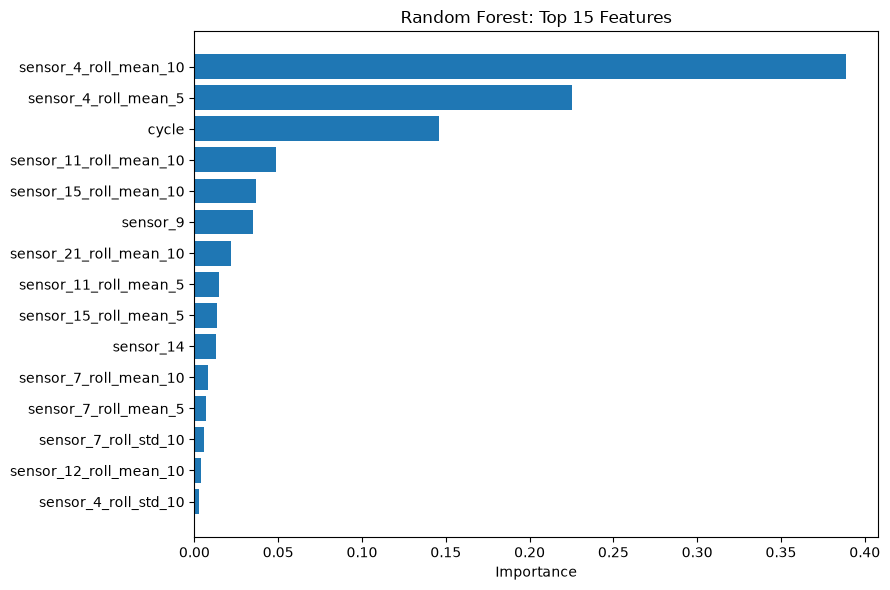

In [61]:
# Random Forest feature importance

plt.figure(figsize=(9, 6))

plt.barh(
    rf_top_features["feature"][::-1],
    rf_top_features["random_forest"][::-1],
)

plt.xlabel("Importance")
plt.title("Random Forest: Top 15 Features")
plt.tight_layout()
plt.show()

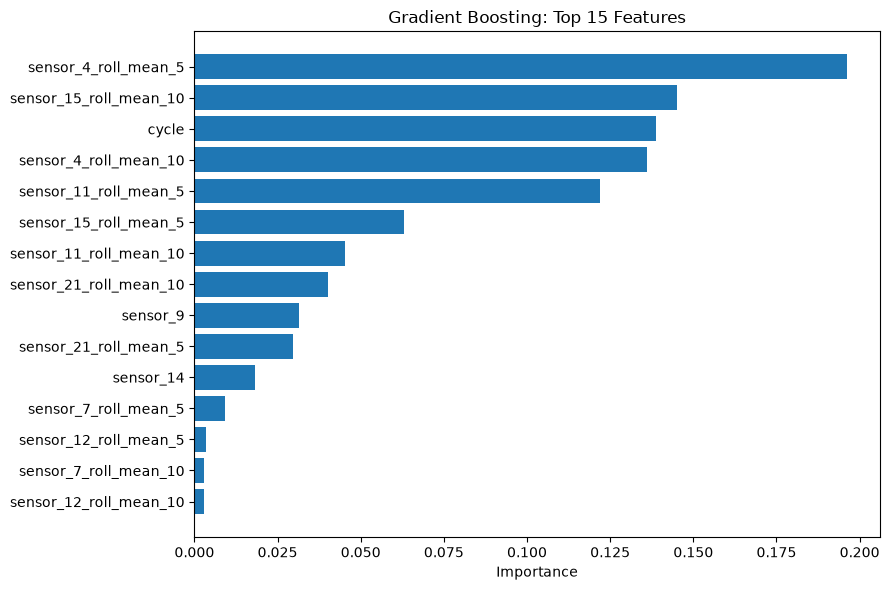

In [62]:
# Gradient Boosting feature importance

plt.figure(figsize=(9, 6))

plt.barh(
    gb_top_features["feature"][::-1],
    gb_top_features["gradient_boosting"][::-1],
)

plt.xlabel("Importance")
plt.title("Gradient Boosting: Top 15 Features")
plt.tight_layout()
plt.show()

In [71]:
# Error analysis by true RUL range, retained from advanced teammate modeling.
def rul_band(values: pd.Series) -> pd.Categorical:
    return pd.cut(
        values,
       bins=[-1, 25, 50, 100, RUL_CAP],
       labels=["0-25", "26-50", "51-100", "101-125"],
    )

rf_error_analysis = pd.DataFrame({
    "actual_rul": y_val.to_numpy(),
    "predicted_rul": rf_val_pred,
})
rf_error_analysis["error"] = (
    rf_error_analysis["predicted_rul"]
    - rf_error_analysis["actual_rul"]
)
rf_error_analysis["rul_band"] = rul_band(
    rf_error_analysis["actual_rul"]
)

display(
    rf_error_analysis.groupby("rul_band", observed=False)
    .agg(
        observations=("error", "size"),
        mae=("error", lambda values: np.abs(values).mean()),
        mean_signed_error=("error", "mean"),
    )
)

,observations,mae,mean_signed_error
rul_band,,,
0-25,520,4.099020,2.663898
26-50,500,12.075657,8.609821
51-100,1000,17.451881,10.080763
101-125,2050,7.586855,-5.981859


,feature,importance
36,sensor_4_roll_mean_10,0.388616
33,sensor_4_roll_mean_5,0.225530
0,cycle,0.145892
29,sensor_11_roll_mean_10,0.048493
57,sensor_15_roll_mean_10,0.036677
12,sensor_9,0.035019
64,sensor_21_roll_mean_10,0.021565
26,sensor_11_roll_mean_5,0.014677
54,sensor_15_roll_mean_5,0.013631
17,sensor_14,0.013030


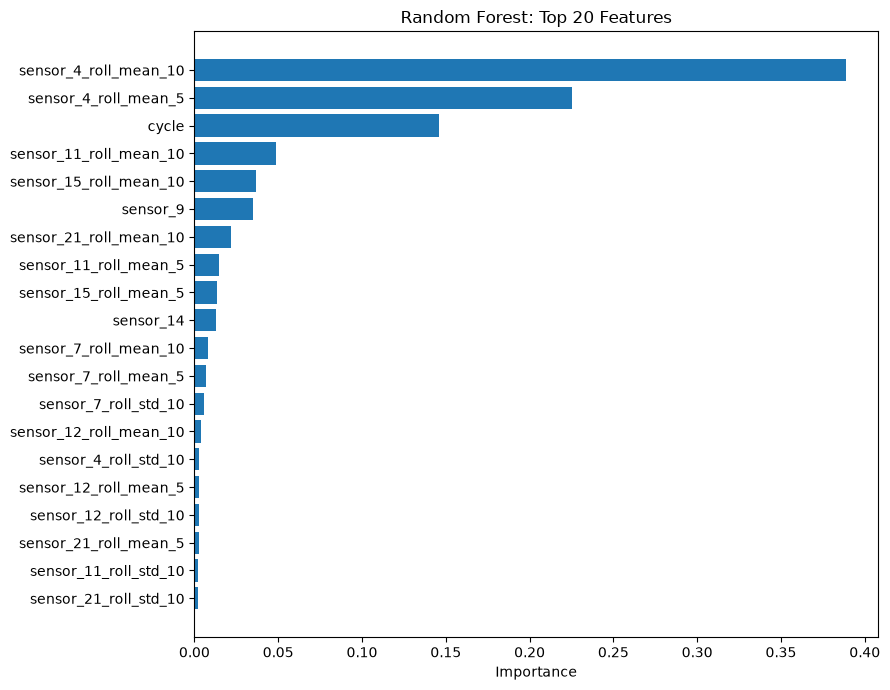

In [72]:
rf_importance = (
    pd.DataFrame({
        "feature": feature_cols,
        "importance": rf_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .head(20)
)

display(rf_importance)

plt.figure(figsize=(9, 7))
plt.barh(
    rf_importance["feature"][::-1],
    rf_importance["importance"][::-1],
)
plt.xlabel("Importance")
plt.title("Random Forest: Top 20 Features")
plt.tight_layout()
plt.show()

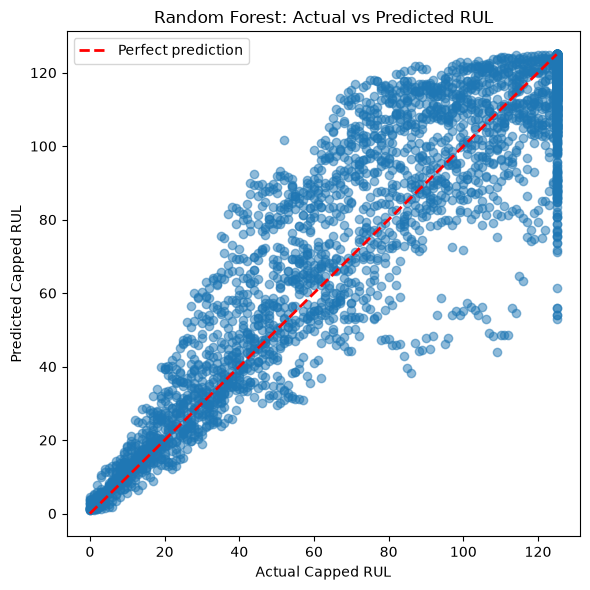

In [73]:
# Actual vs Predicted RUL for Random Forest

plt.figure(figsize=(6, 6))

plt.scatter(
    y_val,
    rf_val_pred,
    alpha=0.5,
)

# Perfect prediction line
min_val = min(y_val.min(), rf_val_pred.min())
max_val = max(y_val.max(), rf_val_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    linewidth=2,
    label="Perfect prediction",
)

plt.xlabel("Actual Capped RUL")
plt.ylabel("Predicted Capped RUL")
plt.title("Random Forest: Actual vs Predicted RUL")
plt.legend()

plt.tight_layout()
plt.show()

# 7. Advanced Machine Learning: XGBoost

In [74]:
initial_xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=200,
    max_depth=3,
    learning_rate=0.10,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)

initial_xgb.fit(X_train, y_train)

initial_xgb_val_pred = np.clip(
    initial_xgb.predict(X_val),
    0,
    RUL_CAP,
)

model_results.append(
    evaluate_regression(
        y_val,
        initial_xgb_val_pred,
        "Initial XGBoost",
    )
)

validation_predictions["Initial XGBoost"] = initial_xgb_val_pred

display(
    pd.DataFrame([
        evaluate_regression(
            y_val,
            initial_xgb_val_pred,
            "Initial XGBoost",
        )
    ]).style.format({
        "rmse": "{:.2f}",
        "mae": "{:.2f}",
        "cmapss_score": "{:,.0f}",
    })
)

,model,rmse,mae,cmapss_score
0,Initial XGBoost,14.80,10.16,"17,026"


In [75]:
# Engine IDs associated with each row in X_train.
training_groups = train_part["unit_id"]

group_cv = GroupKFold(n_splits=3)

xgb_tuning_model = XGBRegressor(
    objective="reg:squarederror",
    subsample=0.80,
    colsample_bytree=0.80,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=1,
    tree_method="hist",
)

parameter_grid = {
    "n_estimators": [200, 400,600],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.03, 0.05, 0.10],
}

grid_search = GridSearchCV(
    estimator=xgb_tuning_model,
    param_grid=parameter_grid,
    scoring="neg_root_mean_squared_error",
    cv=group_cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

grid_search.fit(
    X_train,
    y_train,
    groups=training_groups,
)

tuned_xgb = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print(
    "Best cross-validation RMSE:",
    round(-grid_search.best_score_, 2),
)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


Best parameters: {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 400}
Best cross-validation RMSE: 16.4


The tuned model uses the parameter combination that produced the lowest average RMSE during grouped cross-validation. It is then tested on the 20 validation engines that were not used for training.

In [76]:
tuned_xgb_val_pred = np.clip(
    tuned_xgb.predict(X_val),
    0,
    RUL_CAP,
)

model_results.append(
    evaluate_regression(
        y_val,
        tuned_xgb_val_pred,
        "Tuned XGBoost",
    )
)

validation_predictions["Tuned XGBoost"] = tuned_xgb_val_pred

tuned_xgb_metrics = evaluate_regression(
    y_val,
    tuned_xgb_val_pred,
    "Tuned XGBoost",
)

display(
    pd.DataFrame([tuned_xgb_metrics]).style.format({
        "rmse": "{:.2f}",
        "mae": "{:.2f}",
        "cmapss_score": "{:,.0f}",
    })
)

,model,rmse,mae,cmapss_score
0,Tuned XGBoost,14.74,9.95,"16,869"


In [77]:
xgb_error_analysis = pd.DataFrame({
    "actual_rul": y_val.to_numpy(),
    "predicted_rul": tuned_xgb_val_pred,
})

xgb_error_analysis["error"] = (
    xgb_error_analysis["predicted_rul"]
    - xgb_error_analysis["actual_rul"]
)

xgb_error_analysis["absolute_error"] = (
    xgb_error_analysis["error"].abs()
)

xgb_error_analysis["rul_band"] = rul_band(
    xgb_error_analysis["actual_rul"]
)

xgb_error_by_band = (
    xgb_error_analysis
    .groupby("rul_band", observed=False)
    .agg(
        observations=("error", "size"),
        mae=("absolute_error", "mean"),
        mean_signed_error=("error", "mean"),
    )
    .reset_index()
)

display(
    xgb_error_by_band.style.format({
        "mae": "{:.2f}",
        "mean_signed_error": "{:.2f}",
    })
)

,rul_band,observations,mae,mean_signed_error
0,0-25,520,4.31,2.73
1,26-50,500,11.60,8.10
2,51-100,1000,16.70,9.53
3,101-125,2050,7.68,-6.24


In [78]:
xgb_builtin_importance = (
    pd.DataFrame({
        "feature": feature_cols,
        "xgboost_importance": tuned_xgb.feature_importances_,
    })
    .sort_values("xgboost_importance", ascending=False)
    .head(15)
)

display(xgb_builtin_importance)

,feature,xgboost_importance
33,sensor_4_roll_mean_5,0.271654
26,sensor_11_roll_mean_5,0.146374
57,sensor_15_roll_mean_10,0.135269
36,sensor_4_roll_mean_10,0.130625
29,sensor_11_roll_mean_10,0.064644
54,sensor_15_roll_mean_5,0.060143
0,cycle,0.026372
61,sensor_21_roll_mean_5,0.020186
12,sensor_9,0.019025
47,sensor_7_roll_mean_5,0.012143


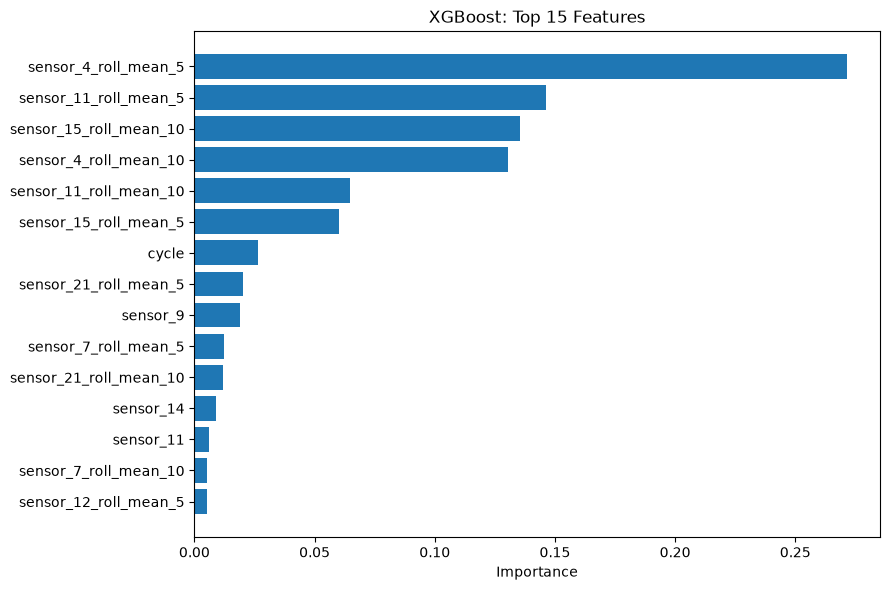

In [79]:
plt.figure(figsize=(9, 6))

plt.barh(
    xgb_builtin_importance["feature"][::-1],
    xgb_builtin_importance["xgboost_importance"][::-1],
)

plt.xlabel("Importance")
plt.title("XGBoost: Top 15 Features")
plt.tight_layout()
plt.show()

#### Permutation Importance

In [82]:
permutation = permutation_importance(
    tuned_xgb,
    X_val,
    y_val,
    scoring="neg_root_mean_squared_error",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_permutation_importance = (
    pd.DataFrame({
        "feature": feature_cols,
        "permutation_importance": permutation.importances_mean,
    })
    .sort_values("permutation_importance", ascending=False)
    .head(15)
)

display(xgb_permutation_importance)

,feature,permutation_importance
0,cycle,6.341588
26,sensor_11_roll_mean_5,2.963769
33,sensor_4_roll_mean_5,1.896123
12,sensor_9,1.427466
57,sensor_15_roll_mean_10,0.938377
17,sensor_14,0.816736
54,sensor_15_roll_mean_5,0.631174
64,sensor_21_roll_mean_10,0.577707
61,sensor_21_roll_mean_5,0.363588
40,sensor_12_roll_mean_5,0.279532


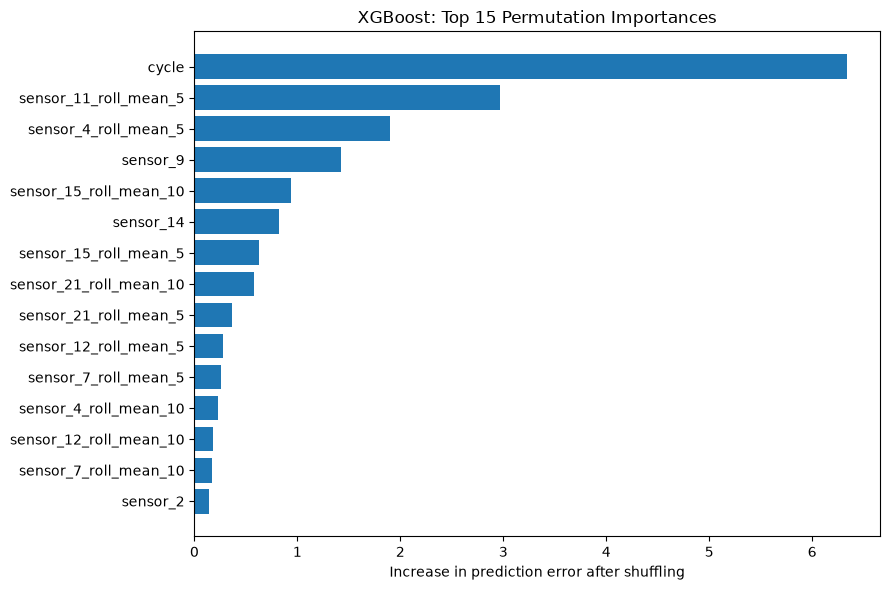

In [83]:
plt.figure(figsize=(9, 6))

plt.barh(
    xgb_permutation_importance["feature"][::-1],
    xgb_permutation_importance["permutation_importance"][::-1],
)

plt.xlabel("Increase in prediction error after shuffling")
plt.title("XGBoost: Top 15 Permutation Importances")
plt.tight_layout()
plt.show()

# 8. Combined Tabular Model Comparison

In [84]:
# 8. Combined comparison of all tabular models

tabular_model_comparison = (
    pd.DataFrame(model_results)
    .drop_duplicates(
        subset="model",
        keep="last",
    )
    .sort_values(
        ["rmse", "mae", "cmapss_score"],
        ascending=True,
    )
    .reset_index(drop=True)
)

display(
    tabular_model_comparison.style.format({
        "rmse": "{:.2f}",
        "mae": "{:.2f}",
        "cmapss_score": "{:,.0f}",
    })
)

,model,rmse,mae,cmapss_score
0,Tuned XGBoost,14.74,9.95,"16,869"
1,Gradient Boosting,14.80,10.23,"16,628"
2,Initial XGBoost,14.80,10.16,"17,026"
3,Random Forest,15.37,10.12,"19,727"
4,Linear Regression,17.06,12.88,"19,908"
5,Mean Baseline,41.72,36.93,"1,285,856"


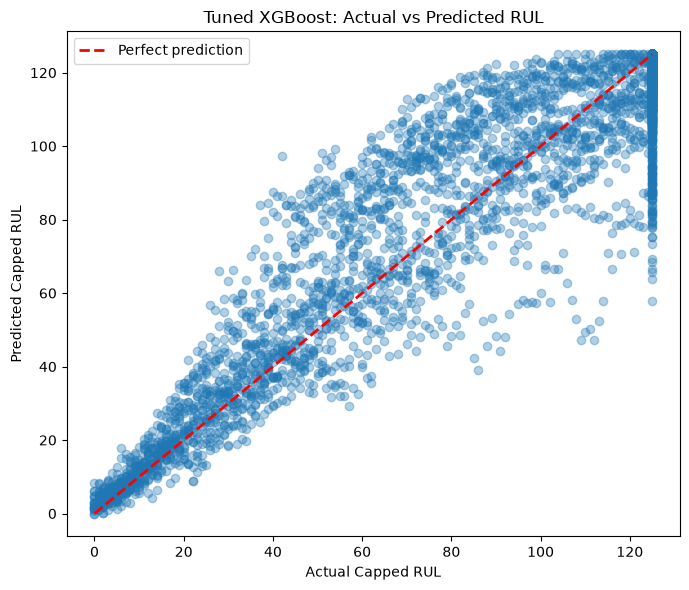

Best tabular model: Tuned XGBoost


In [89]:
best_tabular_model_name = tabular_model_comparison.iloc[0]["model"]
best_tabular_predictions = validation_predictions[best_tabular_model_name]

plt.figure(figsize=(7, 6))

plt.scatter(
    y_val,
    best_tabular_predictions,
    alpha=0.35,
)

# Limits for the perfect prediction line
plot_min = min(
    float(y_val.min()),
    float(best_tabular_predictions.min()),
)

plot_max = max(
    float(y_val.max()),
    float(best_tabular_predictions.max()),
)

# Perfect prediction line
plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    "r--",
    linewidth=2,
    label="Perfect prediction",
)

plt.xlabel("Actual Capped RUL")
plt.ylabel("Predicted Capped RUL")
plt.title(f"{best_tabular_model_name}: Actual vs Predicted RUL")
plt.legend()

plt.tight_layout()
plt.show()

print("Best tabular model:", best_tabular_model_name)

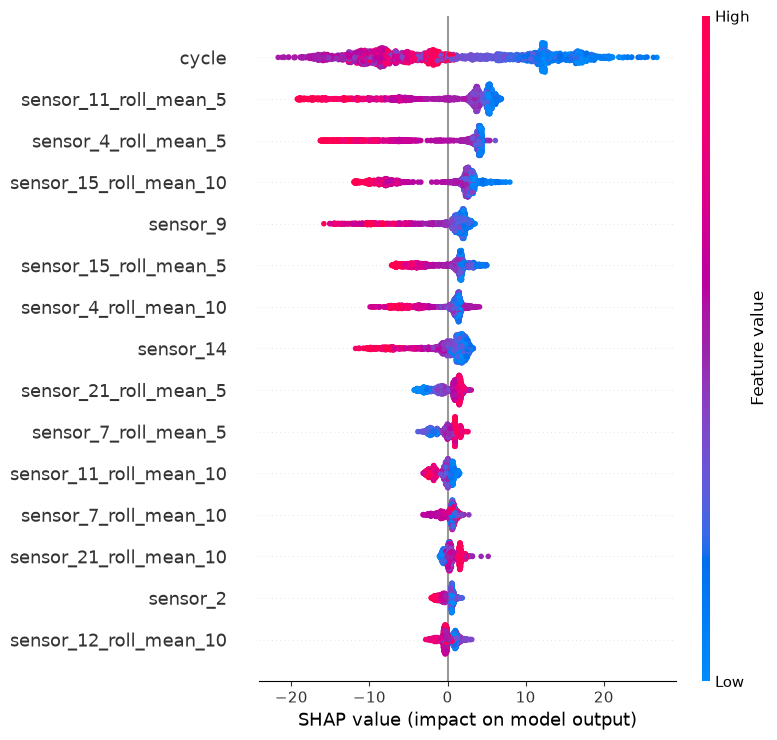

In [90]:
import shap

# Use a sample to keep SHAP computation manageable.
X_shap = X_val.sample(
    n=min(2000, len(X_val)),
    random_state=RANDOM_STATE,
)

# Explain the tuned XGBoost model.
explainer = shap.TreeExplainer(tuned_xgb)
shap_values = explainer.shap_values(X_shap)

# Overall importance and direction of impact.
shap.summary_plot(
    shap_values,
    X_shap,
    max_display=15,
)

The SHAP summary plot explains how each feature influences the XGBoost predictions. Features at the top have the greatest overall impact. Lower cycle values generally increase the predicted RUL, while higher cycle values decrease it. Several engineered rolling-average sensor features also have a strong influence, indicating that recent sensor trends improve the model's ability to estimate remaining useful life.

The operating cycle had the largest influence on the model because it represents the engine's age, while the engineered rolling-average sensor features provided additional information about the engine's recent degradation

# 8. Recurrent neural networks: shared sequence pipeline

In [91]:
try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, Dataset
except ImportError as error:
    raise ImportError(
        "Install PyTorch in the active environment before running this section."
    ) from error

torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", DEVICE)

Device: mps


In [92]:
# RNNs receive raw sensor trajectories, not rolling features.
# Settings are retained as operating context; low-variance columns are removed.
sequence_features = [
    column
    for column in setting_cols + selected_sensors
    if column not in low_variance_cols
]

# Reload clean values because tabular feature frames contain derived columns.
sequence_train = train[
    ["unit_id", "cycle", "rul_capped"] + sequence_features
].copy()
sequence_test = test_raw[
    ["unit_id", "cycle"] + sequence_features
].copy()

train_engine_ids = set(train_part["unit_id"].unique())
val_engine_ids = set(val_part["unit_id"].unique())

sequence_train_part = sequence_train[
    sequence_train["unit_id"].isin(train_engine_ids)
].copy()
sequence_val_part = sequence_train[
    sequence_train["unit_id"].isin(val_engine_ids)
].copy()

sequence_scaler = StandardScaler()
sequence_scaler.fit(sequence_train_part[sequence_features])

sequence_train_part.loc[:, sequence_features] = (
    sequence_scaler.transform(sequence_train_part[sequence_features])
)
sequence_val_part.loc[:, sequence_features] = (
    sequence_scaler.transform(sequence_val_part[sequence_features])
)

print("Sequence features:", sequence_features)

Sequence features: ['setting_1', 'setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [94]:
def build_train_sequences(
    df: pd.DataFrame,
    features: list[str],
    target: str,
    sequence_length: int,
):
    X, y, unit_ids = [], [], []

    for unit_id, engine in df.groupby("unit_id"):
        engine = engine.sort_values("cycle")
        values = engine[features].to_numpy(dtype=np.float32)
        targets = engine[target].to_numpy(dtype=np.float32)

        if len(engine) < sequence_length:
            continue

        for end in range(sequence_length, len(engine) + 1):
            start = end - sequence_length
            X.append(values[start:end])
            y.append(targets[end - 1])
            unit_ids.append(unit_id)

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        np.asarray(unit_ids),
    )


X_train_seq, y_train_seq, train_seq_units = build_train_sequences(
    sequence_train_part,
    sequence_features,
    "rul_capped",
    SEQUENCE_LENGTH,
)
X_val_seq, y_val_seq, val_seq_units = build_train_sequences(
    sequence_val_part,
    sequence_features,
    "rul_capped",
    SEQUENCE_LENGTH,
)

print("Train sequences:", X_train_seq.shape)
print("Validation sequences:", X_val_seq.shape)

Train sequences: (14241, 30, 17)
Validation sequences: (3490, 30, 17)


In [95]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(
            X.astype(np.float32, copy=False)
        )
        self.y = torch.from_numpy(
            y.astype(np.float32, copy=False)
        ).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]


train_loader = DataLoader(
    SequenceDataset(X_train_seq, y_train_seq),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)
val_loader = DataLoader(
    SequenceDataset(X_val_seq, y_val_seq),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

# 9. Configurable LSTM/GRU architecture comparison

In [96]:
class RULRecurrentModel(nn.Module):
    """One configurable implementation for both LSTM and GRU experiments."""

    def __init__(
        self,
        input_size,
        rnn_type="GRU",
        hidden_size=64,
        num_layers=1,
        dropout=0.20,
    ):
        super().__init__()

        rnn_type = rnn_type.upper()
        recurrent_class = {
            "LSTM": nn.LSTM,
            "GRU": nn.GRU,
        }.get(rnn_type)

        if recurrent_class is None:
            raise ValueError("rnn_type must be 'LSTM' or 'GRU'.")

        self.rnn_type = rnn_type
        self.recurrent = recurrent_class(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.regressor = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        output, _ = self.recurrent(x)
        return self.regressor(output[:, -1, :])

In [31]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)

    total_loss = 0.0
    total_examples = 0

    with torch.set_grad_enabled(is_training):
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            if is_training:
                optimizer.zero_grad()

            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            if is_training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=1.0,
                )
                optimizer.step()

            batch_size = X_batch.size(0)
            total_loss += loss.item() * batch_size
            total_examples += batch_size

    return total_loss / total_examples


def predict_loader(model, loader):
    model.eval()
    predictions, actuals = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            predictions.append(
                model(X_batch.to(DEVICE)).cpu().numpy()
            )
            actuals.append(y_batch.numpy())

    return (
        np.concatenate(actuals).ravel(),
        np.concatenate(predictions).ravel(),
    )

In [97]:
def run_recurrent_experiment(config: dict) -> dict:
    """Train one architecture with early stopping and return all artifacts."""
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    torch.manual_seed(RANDOM_STATE)

    model = RULRecurrentModel(
        input_size=len(sequence_features),
        rnn_type=config["rnn_type"],
        hidden_size=config["hidden_size"],
        num_layers=config["num_layers"],
        dropout=config["dropout"],
    ).to(DEVICE)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config.get("learning_rate", 1e-3),
        weight_decay=config.get("weight_decay", 1e-5),
    )

    history = {"train_loss": [], "val_loss": []}
    best_state = None
    best_val_loss = np.inf
    best_epoch = None
    epochs_without_improvement = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
        )
        val_loss = run_epoch(
            model,
            val_loader,
            criterion,
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"{config['name']} | Epoch {epoch:02d} | "
            f"Train RMSE {train_loss ** 0.5:.3f} | "
            f"Val RMSE {val_loss ** 0.5:.3f}"
        )

        if epochs_without_improvement >= PATIENCE:
            print(f"{config['name']}: early stopping.")
            break

    if best_state is None:
        raise RuntimeError("No model state was saved.")

    model.load_state_dict(best_state)
    y_actual, y_pred = predict_loader(model, val_loader)
    y_pred = np.clip(y_pred, 0, None)

    result = evaluate_regression(
        y_actual,
        y_pred,
        config["name"],
    )
    result.update({
        "rnn_type": config["rnn_type"],
        "hidden_size": config["hidden_size"],
        "num_layers": config["num_layers"],
        "dropout": config["dropout"],
        "best_epoch": best_epoch,
    })

    return {
        "model": model,
        "history": history,
        "result": result,
        "config": config,
    }

In [98]:
# Same architecture search space for LSTM and GRU.
recurrent_configs = [
    {
        "name": "LSTM_64x1",
        "rnn_type": "LSTM",
        "hidden_size": 64,
        "num_layers": 1,
        "dropout": 0.20,
    },
    {
        "name": "LSTM_96x2",
        "rnn_type": "LSTM",
        "hidden_size": 96,
        "num_layers": 2,
        "dropout": 0.25,
    },
    {
        "name": "LSTM_128x2",
        "rnn_type": "LSTM",
        "hidden_size": 128,
        "num_layers": 2,
        "dropout": 0.30,
    },
    {
        "name": "GRU_64x1",
        "rnn_type": "GRU",
        "hidden_size": 64,
        "num_layers": 1,
        "dropout": 0.20,
    },
    {
        "name": "GRU_96x2",
        "rnn_type": "GRU",
        "hidden_size": 96,
        "num_layers": 2,
        "dropout": 0.25,
    },
    {
        "name": "GRU_128x2",
        "rnn_type": "GRU",
        "hidden_size": 128,
        "num_layers": 2,
        "dropout": 0.30,
    },
]

recurrent_experiments = {}

for config in recurrent_configs:
    print("\n" + "=" * 72)
    print("Training:", config["name"])
    print("=" * 72)
    recurrent_experiments[config["name"]] = (
        run_recurrent_experiment(config)
    )


Training: LSTM_64x1
LSTM_64x1 | Epoch 01 | Train RMSE 89.141 | Val RMSE 83.958
LSTM_64x1 | Epoch 02 | Train RMSE 79.237 | Val RMSE 72.049
LSTM_64x1 | Epoch 03 | Train RMSE 65.833 | Val RMSE 56.983
LSTM_64x1 | Epoch 04 | Train RMSE 49.612 | Val RMSE 39.075
LSTM_64x1 | Epoch 05 | Train RMSE 32.062 | Val RMSE 23.045
LSTM_64x1 | Epoch 06 | Train RMSE 20.909 | Val RMSE 16.104
LSTM_64x1 | Epoch 07 | Train RMSE 17.500 | Val RMSE 14.325
LSTM_64x1 | Epoch 08 | Train RMSE 15.547 | Val RMSE 12.555
LSTM_64x1 | Epoch 09 | Train RMSE 14.274 | Val RMSE 12.936
LSTM_64x1 | Epoch 10 | Train RMSE 13.694 | Val RMSE 12.289
LSTM_64x1 | Epoch 11 | Train RMSE 13.535 | Val RMSE 12.428
LSTM_64x1 | Epoch 12 | Train RMSE 13.166 | Val RMSE 12.518
LSTM_64x1 | Epoch 13 | Train RMSE 12.730 | Val RMSE 12.185
LSTM_64x1 | Epoch 14 | Train RMSE 12.583 | Val RMSE 14.124
LSTM_64x1 | Epoch 15 | Train RMSE 12.737 | Val RMSE 12.802
LSTM_64x1 | Epoch 16 | Train RMSE 12.301 | Val RMSE 12.361
LSTM_64x1 | Epoch 17 | Train RMSE 1

In [99]:
recurrent_comparison = (
    pd.DataFrame([
        experiment["result"]
        for experiment in recurrent_experiments.values()
    ])
    .sort_values(["cmapss_score", "rmse", "mae"])
    .reset_index(drop=True)
)

display(
    recurrent_comparison.style.format({
        "rmse": "{:.2f}",
        "mae": "{:.2f}",
        "cmapss_score": "{:,.0f}",
        "dropout": "{:.2f}",
    })
)

best_lstm_row = (
    recurrent_comparison[
        recurrent_comparison["rnn_type"] == "LSTM"
    ]
    .sort_values(["cmapss_score", "rmse"])
    .iloc[0]
)
best_gru_row = (
    recurrent_comparison[
        recurrent_comparison["rnn_type"] == "GRU"
    ]
    .sort_values(["cmapss_score", "rmse"])
    .iloc[0]
)

best_lstm_config = recurrent_experiments[
    best_lstm_row["model"]
]["config"]
best_gru_config = recurrent_experiments[
    best_gru_row["model"]
]["config"]

best_lstm_epoch = int(best_lstm_row["best_epoch"])
best_gru_epoch = int(best_gru_row["best_epoch"])

print("Selected LSTM:", best_lstm_config, "Epochs:", best_lstm_epoch)
print("Selected GRU:", best_gru_config, "Epochs:", best_gru_epoch)

,model,rmse,mae,cmapss_score,rnn_type,hidden_size,num_layers,dropout,best_epoch
0,GRU_128x2,12.36,8.91,"8,544",GRU,128,2,0.30,7
1,GRU_64x1,12.30,8.89,"9,122",GRU,64,1,0.20,23
2,LSTM_64x1,12.18,8.47,"9,940",LSTM,64,1,0.20,13
3,GRU_96x2,12.22,8.88,"9,966",GRU,96,2,0.25,7
4,LSTM_128x2,12.32,8.80,"10,335",LSTM,128,2,0.30,8
5,LSTM_96x2,12.47,8.68,"10,799",LSTM,96,2,0.25,10


Selected LSTM: {'name': 'LSTM_64x1', 'rnn_type': 'LSTM', 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2} Epochs: 13
Selected GRU: {'name': 'GRU_128x2', 'rnn_type': 'GRU', 'hidden_size': 128, 'num_layers': 2, 'dropout': 0.3} Epochs: 7


### Interpretation

The architecture comparison is performed only on the 80/20 engine split. Increasing hidden size or stacking recurrent layers is retained only when it improves held-out validation performance. A simpler 64-unit, one-layer model is a valid outcome: FD001 has one operating condition and one fault mode, so additional capacity can overfit rather than help.

# 10. Final recurrent-model training and official NASA test evaluation

In [100]:
# Fit preprocessing again using every training engine.
full_sequence_scaler = StandardScaler()
full_sequence_scaler.fit(sequence_train[sequence_features])

full_train_scaled = sequence_train.copy()
full_test_scaled = sequence_test.copy()

full_train_scaled.loc[:, sequence_features] = (
    full_sequence_scaler.transform(
        full_train_scaled[sequence_features]
    )
)
full_test_scaled.loc[:, sequence_features] = (
    full_sequence_scaler.transform(
        full_test_scaled[sequence_features]
    )
)

X_all_seq, y_all_seq, all_seq_units = build_train_sequences(
    full_train_scaled,
    sequence_features,
    "rul_capped",
    SEQUENCE_LENGTH,
)

all_train_loader = DataLoader(
    SequenceDataset(X_all_seq, y_all_seq),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

print("All-training sequences:", X_all_seq.shape)

All-training sequences: (17731, 30, 17)


In [101]:
def build_last_sequences(
    df: pd.DataFrame,
    features: list[str],
    sequence_length: int,
):
    X, unit_ids = [], []

    for unit_id, engine in df.groupby("unit_id"):
        engine = engine.sort_values("cycle")
        values = engine[features].to_numpy(dtype=np.float32)

        if len(values) >= sequence_length:
            sequence = values[-sequence_length:]
        else:
            # General safeguard for short test histories.
            padding = np.repeat(
                values[[0]],
                sequence_length - len(values),
                axis=0,
            )
            sequence = np.vstack([padding, values])

        X.append(sequence)
        unit_ids.append(unit_id)

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(unit_ids),
    )


X_test_last_seq, test_unit_ids = build_last_sequences(
    full_test_scaled,
    sequence_features,
    SEQUENCE_LENGTH,
)

test_truth_aligned = (
    test_last_truth
    .sort_values("unit_id")
    .reset_index(drop=True)
)

assert np.array_equal(
    test_unit_ids,
    test_truth_aligned["unit_id"].to_numpy(),
)

y_test_actual = test_truth_aligned[
    "actual_rul"
].to_numpy(dtype=np.float32)

print("Official test sequences:", X_test_last_seq.shape)

Official test sequences: (100, 30, 17)


In [102]:
def train_fixed_epochs(
    config: dict,
    epochs: int,
):
    """Retrain a fresh selected model on all training engines."""
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    torch.manual_seed(RANDOM_STATE)

    model = RULRecurrentModel(
        input_size=len(sequence_features),
        rnn_type=config["rnn_type"],
        hidden_size=config["hidden_size"],
        num_layers=config["num_layers"],
        dropout=config["dropout"],
    ).to(DEVICE)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config.get("learning_rate", 1e-3),
        weight_decay=config.get("weight_decay", 1e-5),
    )

    history = []

    for epoch in range(1, epochs + 1):
        loss = run_epoch(
            model,
            all_train_loader,
            criterion,
            optimizer,
        )
        history.append(loss)
        print(
            f"{config['name']} | Epoch {epoch:02d}/{epochs:02d} | "
            f"Train RMSE {loss ** 0.5:.3f}"
        )

    return model, history


final_lstm, final_lstm_history = train_fixed_epochs(
    best_lstm_config,
    best_lstm_epoch,
)
final_gru, final_gru_history = train_fixed_epochs(
    best_gru_config,
    best_gru_epoch,
)

LSTM_64x1 | Epoch 01/13 | Train RMSE 87.966
LSTM_64x1 | Epoch 02/13 | Train RMSE 74.597
LSTM_64x1 | Epoch 03/13 | Train RMSE 55.897
LSTM_64x1 | Epoch 04/13 | Train RMSE 34.128
LSTM_64x1 | Epoch 05/13 | Train RMSE 20.179
LSTM_64x1 | Epoch 06/13 | Train RMSE 16.225
LSTM_64x1 | Epoch 07/13 | Train RMSE 14.540
LSTM_64x1 | Epoch 08/13 | Train RMSE 13.875
LSTM_64x1 | Epoch 09/13 | Train RMSE 13.515
LSTM_64x1 | Epoch 10/13 | Train RMSE 13.680
LSTM_64x1 | Epoch 11/13 | Train RMSE 13.355
LSTM_64x1 | Epoch 12/13 | Train RMSE 13.014
LSTM_64x1 | Epoch 13/13 | Train RMSE 13.090
GRU_128x2 | Epoch 01/07 | Train RMSE 80.788
GRU_128x2 | Epoch 02/07 | Train RMSE 54.376
GRU_128x2 | Epoch 03/07 | Train RMSE 25.738
GRU_128x2 | Epoch 04/07 | Train RMSE 15.194
GRU_128x2 | Epoch 05/07 | Train RMSE 14.433
GRU_128x2 | Epoch 06/07 | Train RMSE 14.502
GRU_128x2 | Epoch 07/07 | Train RMSE 13.709


In [103]:
def predict_sequence_array(model, X):
    model.eval()
    loader = DataLoader(
        torch.from_numpy(X.astype(np.float32, copy=False)),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )

    predictions = []

    with torch.no_grad():
        for X_batch in loader:
            predictions.append(
                model(X_batch.to(DEVICE)).cpu().numpy()
            )

    return np.clip(
        np.concatenate(predictions).ravel(),
        0,
        None,
    )


lstm_test_pred = predict_sequence_array(
    final_lstm,
    X_test_last_seq,
)
gru_test_pred = predict_sequence_array(
    final_gru,
    X_test_last_seq,
)

official_test_results = (
    pd.DataFrame([
        evaluate_regression(
            y_test_actual,
            lstm_test_pred,
            best_lstm_config["name"],
        ),
        evaluate_regression(
            y_test_actual,
            gru_test_pred,
            best_gru_config["name"],
        ),
    ])
    .sort_values(["cmapss_score", "rmse", "mae"])
    .reset_index(drop=True)
)

display(
    official_test_results.style.format({
        "rmse": "{:.2f}",
        "mae": "{:.2f}",
        "cmapss_score": "{:,.0f}",
    })
)

,model,rmse,mae,cmapss_score
0,GRU_128x2,15.10,11.20,409
1,LSTM_64x1,16.16,11.44,413


GRU training curves
        
Comparison table
        
Actual vs Predicted (GRU)
        
Final comparison with all model

In [104]:
official_test_predictions = pd.DataFrame({
    "unit_id": test_unit_ids,
    "actual_rul": y_test_actual,
    "lstm_predicted_rul": lstm_test_pred,
    "gru_predicted_rul": gru_test_pred,
})
official_test_predictions["lstm_error"] = (
    official_test_predictions["lstm_predicted_rul"]
    - official_test_predictions["actual_rul"]
)
official_test_predictions["gru_error"] = (
    official_test_predictions["gru_predicted_rul"]
    - official_test_predictions["actual_rul"]
)

official_test_predictions.to_csv(
    PREDICTIONS_DIR / "official_lstm_gru_test_predictions.csv",
    index=False,
)
official_test_results.to_csv(
    REPORTS_DIR / "official_lstm_gru_test_results.csv",
    index=False,
)

torch.save(
    {
        "config": best_lstm_config,
        "epochs": best_lstm_epoch,
        "sequence_features": sequence_features,
        "sequence_length": SEQUENCE_LENGTH,
        "state_dict": final_lstm.state_dict(),
    },
    MODELS_DIR / "final_lstm_fd001.pt",
)
torch.save(
    {
        "config": best_gru_config,
        "epochs": best_gru_epoch,
        "sequence_features": sequence_features,
        "sequence_length": SEQUENCE_LENGTH,
        "state_dict": final_gru.state_dict(),
    },
    MODELS_DIR / "final_gru_fd001.pt",
)

display(official_test_predictions.head())

,unit_id,actual_rul,lstm_predicted_rul,gru_predicted_rul,lstm_error,gru_error
0,1,112.0,111.529861,112.820366,-0.470139,0.820366
1,2,98.0,114.545891,120.560303,16.545891,22.560303
2,3,69.0,45.465965,50.503830,-23.534035,-18.496170
3,4,82.0,79.440819,80.313400,-2.559181,-1.686600
4,5,91.0,103.471382,106.872375,12.471382,15.872375


# 11. Benchmark context and feature-engineering diagnosis

The following benchmark context is included to prevent overclaiming:

- A 2026 comparative study reported a simple single-layer LSTM FD001 RMSE of **14.93**, showing that simple recurrent models can be competitive but results depend strongly on preprocessing.
- A 2026 CNN–GRU study reported FD001 RMSE **13.1 ± 0.4** using a 30-cycle window, RUL cap 125, learning-rate scheduling, and repeated runs.
- A 2026 reproducibility study found that a reproduced Transformer-based method averaged **15.99 ± 1.39**, despite a lower originally reported single-run value. This shows why one online score should not be treated as an absolute standard.
- More advanced residual/attention methods report values near 11–12, but they use materially different architectures and representation learning.

### What likely limits the current model

1. **Single-run variance:** recurrent results can change with initialization.
2. **No learning-rate scheduler:** `ReduceLROnPlateau` may improve convergence.
3. **No convolutional front end:** a CNN can learn local cross-sensor patterns before the GRU.
4. **Single sequence scale:** multi-scale windows can capture both short and long degradation trends.
5. **RUL label assumption:** a fixed cap of 125 is reasonable but not universally optimal.
6. **Validation objective:** selecting by RMSE and selecting by asymmetric C-MAPSS score can choose different epochs/models.

### Recommended scope

For this course project, retain the current LSTM/GRU comparison and PEAS agent. Treat CNN–GRU, scheduler tuning, repeated seeds, and change-point labeling as future work rather than expanding the implementation indefinitely.

Sources:
- https://arxiv.org/abs/2604.27234
- https://doi.org/10.1155/er/7022062
- https://www.insticc.org/node/TechnicalProgram/data/2026/presentationDetails/150760
- https://link.springer.com/article/10.1007/s10791-026-10000-8

# 12. PEAS-based maintenance decision agent

# 12  PEAS- Maintenance Decision-Support Agent

- **Performance measure:** minimize late-failure risk and unnecessary early maintenance while respecting maintenance-bay capacity.
- **Environment:** a fleet of test engines with independently evolving degradation and a limited number of maintenance slots.
- **Actuators:** assign an engine to maintenance now, rank it in the queue, or defer it.
- **Sensors:** predicted RUL, model disagreement, and current maintenance capacity.

This turns RUL prediction into a rational, utility-based maintenance decision rather than a simple sorting exercise.

In [108]:

# ---------------------------------------------------------
# 1. Select the better recurrent model
# ---------------------------------------------------------

# This assumes official_test_results is sorted so that
# the best-performing model appears in the first row.
selected_model_name = official_test_results.iloc[0]["model"]

if selected_model_name == best_gru_config["name"]:
    selected_prediction = gru_test_pred
else:
    selected_prediction = lstm_test_pred

print("Selected recurrent model:", selected_model_name)


# ---------------------------------------------------------
# 2. Create one record for each test engine
# ---------------------------------------------------------

agent_input = pd.DataFrame({
    "unit_id": test_unit_ids,

    # Predicted remaining useful life from the selected model.
    "predicted_rul": selected_prediction,

    # Difference between LSTM and GRU predictions.
    # Large disagreement is treated as a warning signal.
    "model_disagreement": np.abs(
        lstm_test_pred - gru_test_pred
    ),
})


# ---------------------------------------------------------
# 3. Convert predicted RUL into risk categories
# ---------------------------------------------------------

def classify_risk(predicted_rul: float) -> str:
    """Assign an illustrative risk level based on predicted RUL."""

    if predicted_rul <= 15:
        return "Critical"

    if predicted_rul <= 30:
        return "High"

    if predicted_rul <= 60:
        return "Medium"

    return "Low"


agent_input["risk_tier"] = (
    agent_input["predicted_rul"]
    .map(classify_risk)
)


# ---------------------------------------------------------
# 4. Flag engines where the models strongly disagree
# ---------------------------------------------------------

# This is an illustrative threshold for the class project.
# A real system would set it using operational requirements.
DISAGREEMENT_THRESHOLD = 10.0

agent_input["review_flag"] = np.where(
    agent_input["model_disagreement"] >= DISAGREEMENT_THRESHOLD,
    "Manual review",
    "Normal",
)


# ---------------------------------------------------------
# 5. Calculate urgency
# ---------------------------------------------------------

# Lower predicted RUL produces a higher urgency score.
# Model disagreement is kept separate as a review flag.
agent_input["urgency_score"] = (
    100.0 / (agent_input["predicted_rul"] + 1.0)
)


# ---------------------------------------------------------
# 6. Rank engines from most urgent to least urgent
# ---------------------------------------------------------

maintenance_queue = (
    agent_input
    .sort_values(
        by=["urgency_score", "predicted_rul"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

maintenance_queue["queue_position"] = (
    np.arange(1, len(maintenance_queue) + 1)
)


# ---------------------------------------------------------
# 7. Recommend an action based on risk
# ---------------------------------------------------------

def recommend_action(row: pd.Series) -> str:
    """Recommend an action based on risk and model agreement."""

    if row["review_flag"] == "Manual review":
        return "Inspect / review prediction"

    if row["risk_tier"] == "Critical":
        return "Schedule immediately"

    if row["risk_tier"] == "High":
        return "Schedule soon"

    if row["risk_tier"] == "Medium":
        return "Monitor closely"

    return "Continue normal monitoring"


maintenance_queue["recommended_action"] = (
    maintenance_queue.apply(
        recommend_action,
        axis=1,
    )
)


# ---------------------------------------------------------
# 8. Save the full ranked queue
# ---------------------------------------------------------

REPORTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

display(maintenance_queue.head(20))

maintenance_queue.to_csv(
    REPORTS_DIR / "maintenance_queue.csv",
    index=False,
)


# ---------------------------------------------------------
# 9. Capacity analysis
# ---------------------------------------------------------

# Only Critical and High-risk engines are eligible
# for maintenance scheduling.
# Medium and Low-risk engines are not repaired early,
# even if extra capacity is available.
eligible_queue = (
    maintenance_queue[
        maintenance_queue["risk_tier"]
        .isin(["Critical", "High"])
    ]
    .copy()
)

# Overall number of engines in each risk group.
risk_counts = (
    maintenance_queue["risk_tier"]
    .value_counts()
)

total_critical = int(risk_counts.get("Critical", 0))
total_high = int(risk_counts.get("High", 0))
total_medium = int(risk_counts.get("Medium", 0))
total_low = int(risk_counts.get("Low", 0))

total_high_or_critical = total_critical + total_high

capacity_summary = []

for capacity in [5, 10, 15, 20, 30]:

    # Schedule only eligible High- and Critical-risk engines.
    scheduled = eligible_queue.head(capacity)

    capacity_summary.append({
        "capacity": int(capacity),

        # Overall fleet totals by risk group.
        "total_critical": total_critical,
        "total_high": total_high,
        "total_medium": total_medium,
        "total_low": total_low,
        "total_high_or_critical": total_high_or_critical,

        # Scheduling information.
        "eligible_engines": int(len(eligible_queue)),
        "scheduled_engines": int(len(scheduled)),
        "unused_capacity": int(capacity - len(scheduled)),

        # Risk groups included in the scheduled set.
        "critical_scheduled": int(
            (scheduled["risk_tier"] == "Critical").sum()
        ),
        "high_scheduled": int(
            (scheduled["risk_tier"] == "High").sum()
        ),
        "high_or_critical_scheduled": int(
            scheduled["risk_tier"]
            .isin(["Critical", "High"])
            .sum()
        ),

        "manual_reviews": int(
            (scheduled["review_flag"] == "Manual review").sum()
        ),

        "maximum_scheduled_predicted_rul": (
            float(scheduled["predicted_rul"].max())
            if not scheduled.empty
            else np.nan
        ),
    })

capacity_summary = pd.DataFrame(capacity_summary)

display(capacity_summary)



capacity_summary.to_csv(
    REPORTS_DIR / "maintenance_capacity_analysis.csv",
    index=False,
)

Selected recurrent model: GRU_128x2


,unit_id,predicted_rul,model_disagreement,risk_tier,review_flag,urgency_score,queue_position,recommended_action
0,34,5.156353,3.110513,Critical,Normal,16.243383,1,Schedule immediately
1,42,5.391364,5.833311,Critical,Normal,15.646113,2,Schedule immediately
2,81,6.009723,1.531858,Critical,Normal,14.265899,3,Schedule immediately
3,82,6.159860,5.139734,Critical,Normal,13.966753,4,Schedule immediately
4,68,6.801624,5.306049,Critical,Normal,12.817844,5,Schedule immediately
5,76,7.178317,3.644131,Critical,Normal,12.227456,6,Schedule immediately
6,31,8.606690,3.033096,Critical,Normal,10.409412,7,Schedule immediately
7,35,9.841004,1.290466,Critical,Normal,9.224237,8,Schedule immediately
8,56,14.963373,0.750175,Critical,Normal,6.264340,9,Schedule immediately
9,20,16.981056,1.039845,High,Normal,5.561409,10,Schedule soon


,capacity,total_critical,total_high,total_medium,total_low,total_high_or_critical,eligible_engines,scheduled_engines,unused_capacity,critical_scheduled,high_scheduled,high_or_critical_scheduled,manual_reviews,maximum_scheduled_predicted_rul
0,5,9,14,14,63,23,23,5,0,5,0,5,0,6.801624
1,10,9,14,14,63,23,23,10,0,9,1,10,0,16.981056
2,15,9,14,14,63,23,23,15,0,9,6,15,0,23.276764
3,20,9,14,14,63,23,23,20,0,9,11,20,0,27.777950
4,30,9,14,14,63,23,23,23,7,9,14,23,0,29.729036


# 13. Final conclusions and limitations

### Main conclusions

- Engine-level splitting is essential because cycles from the same engine are not independent.
- Temporal rolling features strengthen tabular models without using future information.
- Recurrent models can capture degradation trajectories that row-wise models cannot directly represent.
- Architecture complexity should be justified by validation performance; deeper models are not automatically better.
- The PEAS agent converts prognostic output into an operational maintenance queue under a capacity constraint.

### Limitations

- FD001 contains only one operating condition and one fault mode.
- The sensor channels are anonymized, limiting physical interpretation.
- The current uncertainty proxy is model disagreement, not a calibrated probabilistic interval.
- Results are based on one primary random seed unless repeated-run analysis is added.
- Online benchmark comparisons remain approximate unless the preprocessing and evaluation protocol are identical.